Aqui va todo de lo que estoy seguro de usar

In [1]:
from limpio import *
import numpy as np
from sklearn.preprocessing import RobustScaler
from keras.callbacks import EarlyStopping
import torch.nn as nn
import torch
import pandas as pd


In [2]:
MINUTES = 60

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4518540
✅ Agregado: 5min | Filas: 915307
✅ Agregado: 15min | Filas: 306022
✅ Agregado: 30min | Filas: 154771
✅ Agregado: 60min | Filas: 78017


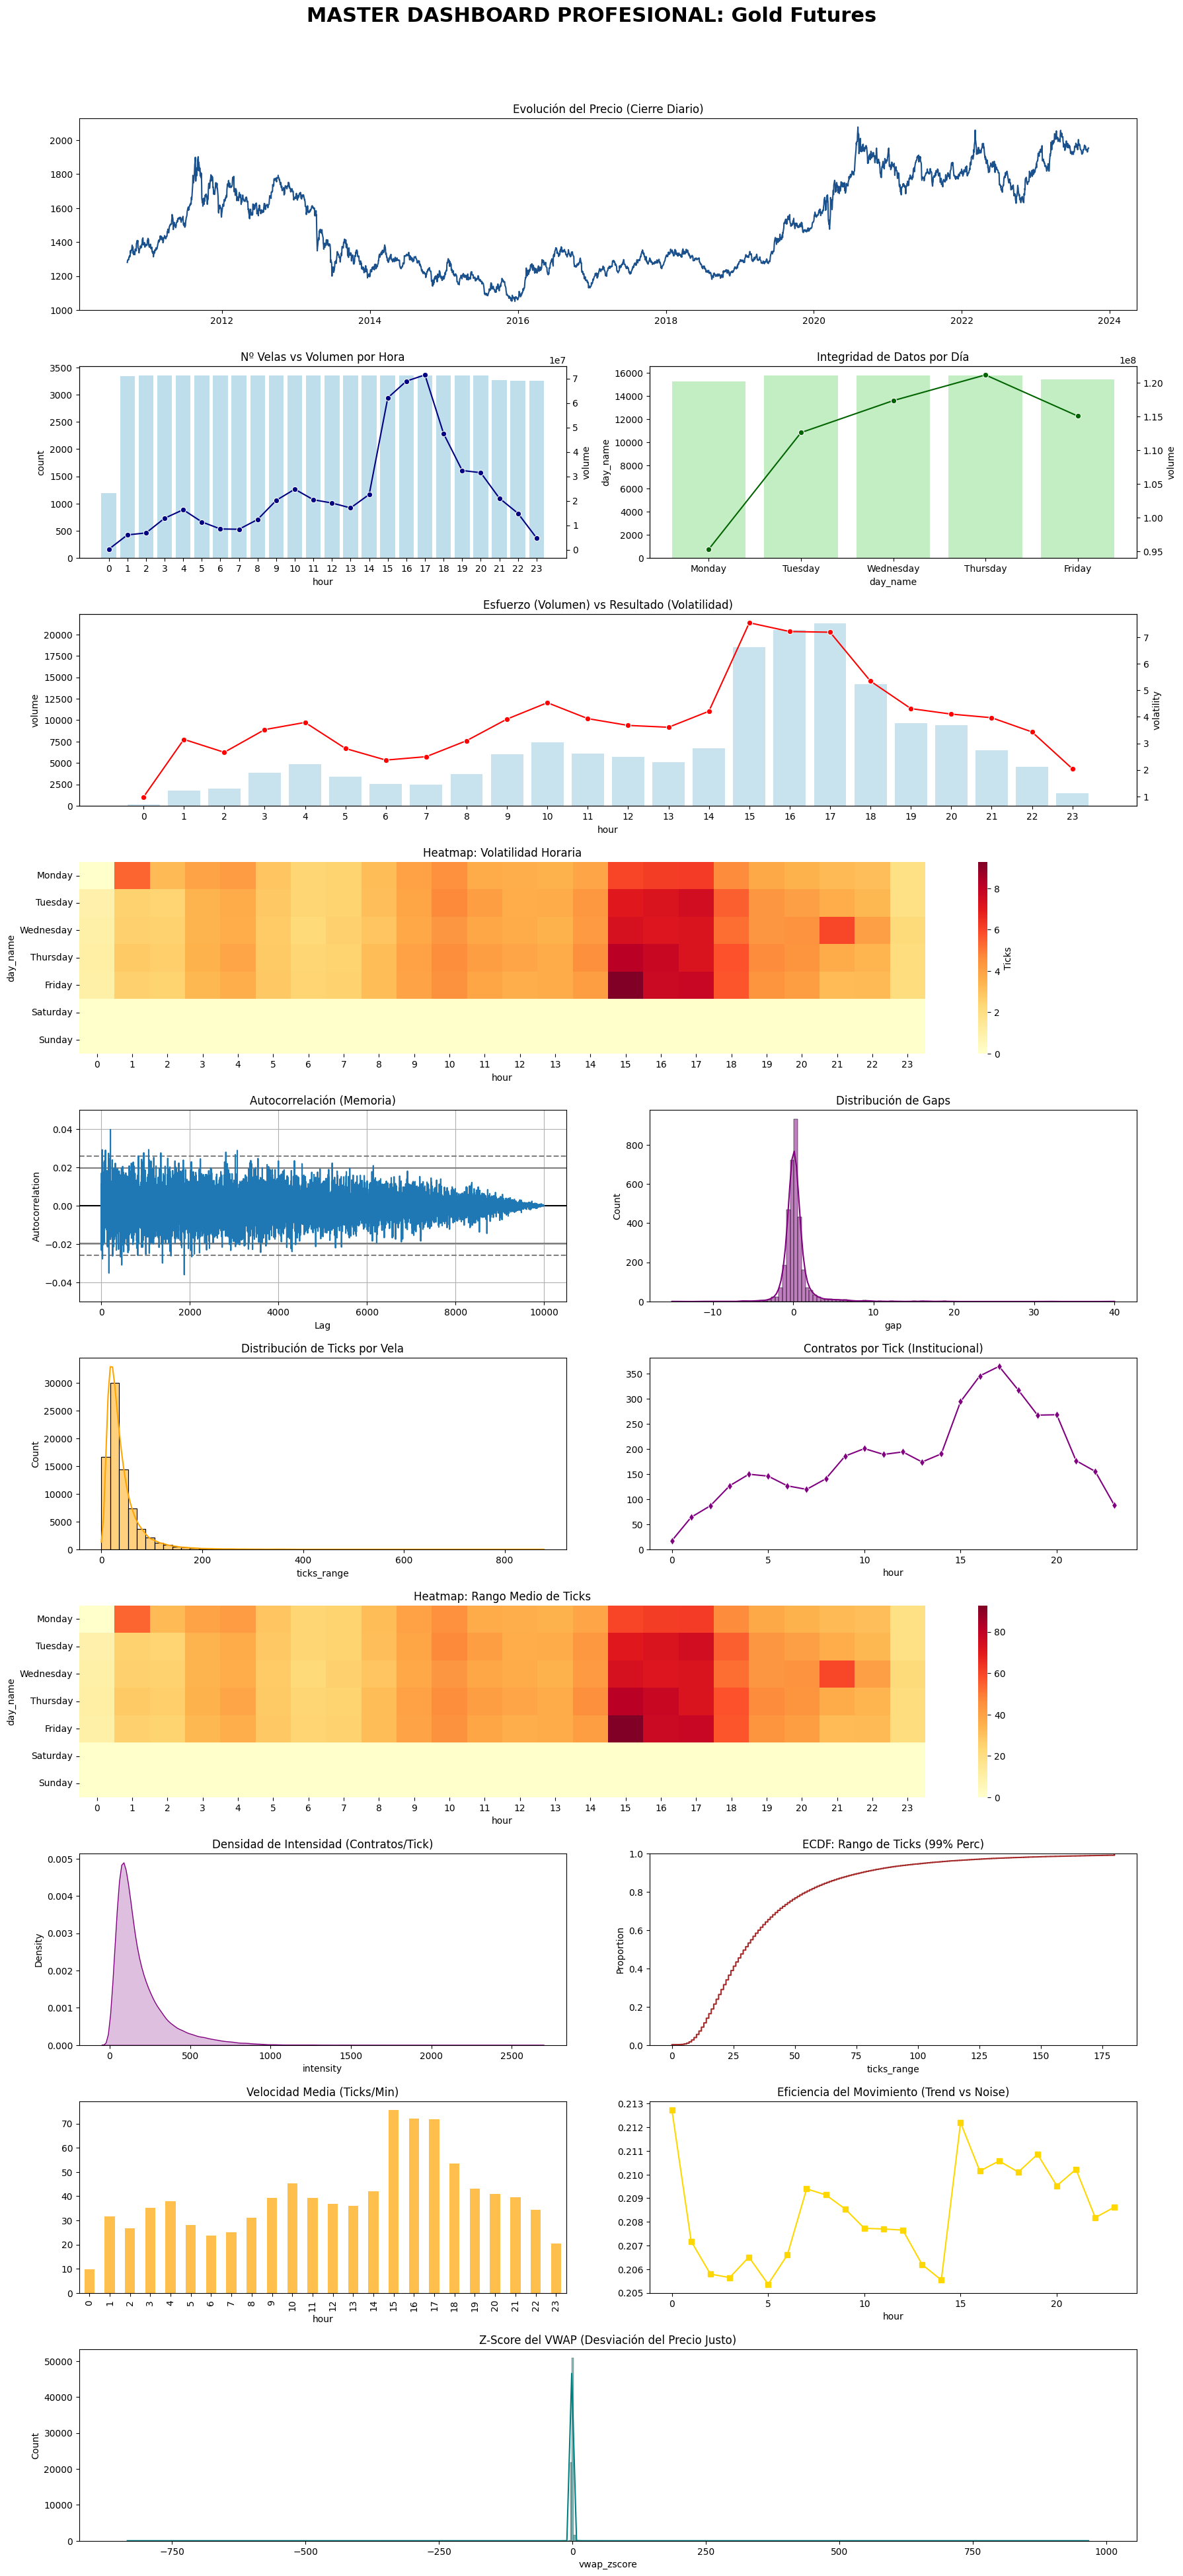

In [3]:
df_min, spec = import_dataset()
df_min_clean = clean(df_min)
df_resampled = get_multitimeframe_data(df_min_clean)
plot_master_market_analysis(df_resampled[f'{MINUTES}min'], asset_name="Gold Futures", tick_size=0.1)

In [4]:
df_cumulative = apply_cumulative_stats_to_dict(df_resampled)

✅ Procesados acumulados diarios para: 5min
✅ Procesados acumulados diarios para: 15min
✅ Procesados acumulados diarios para: 30min
✅ Procesados acumulados diarios para: 60min


In [5]:
df_final_dict = process_full_dictionary(df_cumulative, spec)

🚀 Features generadas para 5min: 92 columnas.
🚀 Features generadas para 15min: 92 columnas.
🚀 Features generadas para 30min: 92 columnas.
🚀 Features generadas para 60min: 92 columnas.


In [6]:
df_final_dict[f'{MINUTES}min'].iloc[0].to_dict()

{'datetime': Timestamp('2010-09-21 04:00:00'),
 'open': 1280.4,
 'high': 1280.5,
 'low': 1279.3,
 'close': 1280.0,
 'volume': 712,
 'openint': 0.0,
 'ticker': 'GC',
 'per': '60min',
 'trading_date': datetime.date(2010, 9, 21),
 'open_day': 1280.4,
 'high_cum': 1281.2,
 'low_cum': 1279.0,
 'volume_cum': 2827,
 'dist_to_high': 1.2000000000000455,
 'dist_to_low': 1.0,
 'step_sin': 0.8660254037844386,
 'step_cos': 0.5000000000000001,
 'dow_sin': 0.7818314824680298,
 'dow_cos': 0.6234898018587336,
 'is_london': 0,
 'is_ny': 0,
 'is_overlap': 0,
 'body_ticks': -4.0000000000009095,
 'range_ticks': 12.000000000000455,
 'upper_wick_ticks': 0.9999999999990905,
 'lower_wick_ticks': 7.000000000000455,
 'body_pct': 0.3333333330556187,
 'upper_wick_pct': 0.08333333326380993,
 'lower_wick_pct': 0.583333332847238,
 'close_location': 0.5833333284722381,
 'dist_high_cum_ticks': 12.000000000000455,
 'dist_low_cum_ticks': 10.0,
 'dist_open_day_ticks': -4.0000000000009095,
 'vol_per_tick': 54.7692307692288

In [7]:
FEATURE_COLUMNS = [
    # --- Ciclos y Tiempo ---
    'step_sin', 'step_cos', 'dow_sin', 'dow_cos',
    
    # --- Sesiones ---
    'is_london', 'is_ny', 'is_overlap',
    
    # --- Acción del Precio (Ticks) ---
    'body_pct', 'upper_wick_pct', 'lower_wick_pct', 'close_location',
    
    # --- Dinámica de Volumen ---
    'vol_per_tick', 'vol_vs_body', 'vol_weight_intraday',
    
    # --- Indicadores y Momentum ---
    'log_ret', 'rsi_14', 'volatility_20', 'efficiency_ratio',
    
    # --- Contexto y Valor ---
    'vwap_zscore', 'dist_sma_20_ticks', 'ticks_velocity',
    
    # --- Posición Diaria ---
    'dist_high_cum_ticks', 'dist_low_cum_ticks', 'dist_open_day_ticks',
    
        # Añade estas 3 a tu lista actual:
    'atr_norm',       # De features.py (Volatilidad relativa)
    'bb_percent_b',   # De features.py (Posición en bandas)
    'clv'             # De features.py (Presión de cierre)
]

TARGET_COLUMN = 'target_bin' # 1 si sube, 0 si baja/lateral

In [8]:
df_final_dict = audit_and_clean_dict(df_final_dict, FEATURE_COLUMNS)

--- 🔍 Auditando 5min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 15min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 30min ---
💎 Datos limpios. Sin NaNs.
-------------------------
--- 🔍 Auditando 60min ---
💎 Datos limpios. Sin NaNs.
-------------------------


In [9]:
result_torch, model, sc = run_walk_forward_pytorch_amp(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS, train_size=5000, test_size=1000, step=500, lookback=24)

🖥️ Usando GPU: NVIDIA GeForce RTX 3060 Laptop GPU con AMP


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1026: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = GradScaler()
e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2010-09-21 OK. Acc: 49.80%


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2010-10-20 OK. Acc: 47.85%


...

✅ Ventana 2022-01-03 OK. Acc: 50.61%


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2022-02-02 OK. Acc: 52.66%


e:\Futuro\MLAlgoTrading\TradingBots\limipio\limpio.py:1063: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


✅ Ventana 2022-03-04 OK. Acc: 52.05%


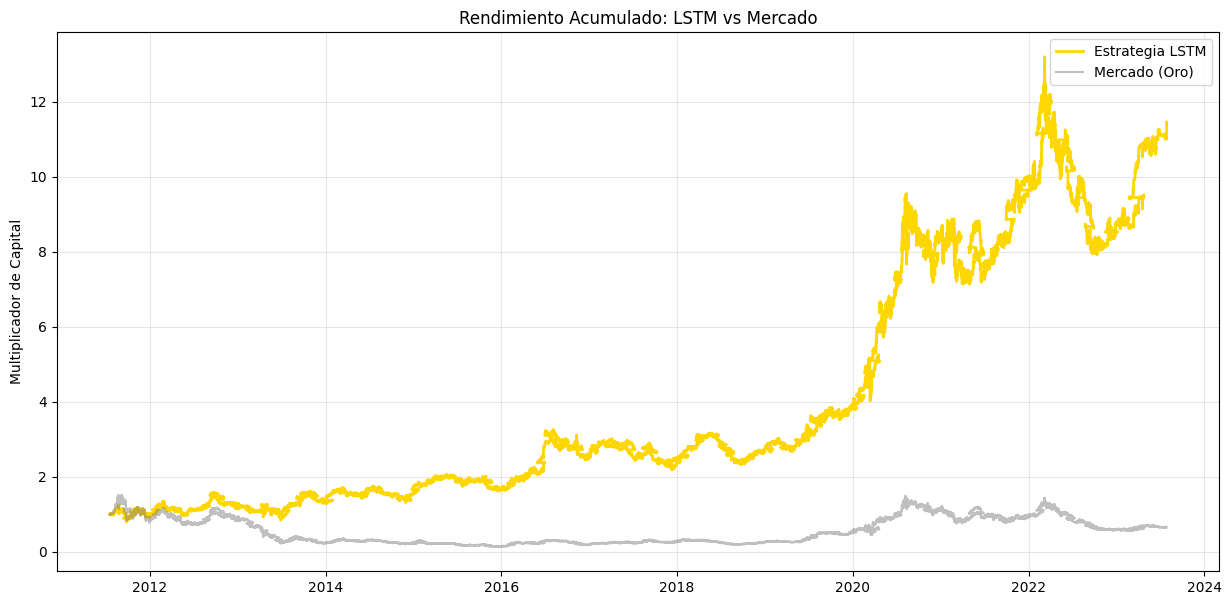

💰 Sharpe Ratio Estimado: 0.16
📈 Retorno Total Estrategia: 1045.72%


In [10]:
plot_trading_results(result_torch)

In [11]:
# Calculamos la volatilidad media (ATR simplificado) para que el umbral sea lógico
volatilidad_media = df_final_dict[f'{MINUTES}min']['target_ret_30m'].abs().mean()
print(f"Volatilidad media cada 30 min: {volatilidad_media:.5f}")

# Umbral: Solo queremos operar si el movimiento esperado es mayor que la media
threshold = volatilidad_media * 0.7

Volatilidad media cada 30 min: 0.00179


In [12]:
# Definir el umbral (ajustar según volatilidad)
# threshold = 0.0005 

def label_triple(ret):
    if ret > threshold:
        return 2 # Buy
    elif ret < -threshold:
        return 0 # Sell
    else:
        return 1 # Neutral

df_final_dict[f'{MINUTES}min']['target_triple'] = df_final_dict[f'{MINUTES}min']['target_ret_30m'].apply(label_triple)

# Verifica el balance de clases
print(df_final_dict[f'{MINUTES}min']['target_triple'].value_counts(normalize=True))

target_triple
1    0.536179
2    0.234612
0    0.229209
Name: proportion, dtype: float64


In [13]:
class GoldLSTM_Triple(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super(GoldLSTM_Triple, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout)
        
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 3) # Salida para: [Sell, Neutral, Buy]

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :] 
        
        out = self.batch_norm(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out) # Retorna logits

In [14]:
class GoldLSTM_V2(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2): # Más ligero
        super(GoldLSTM_V2, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 3) # Directo a las 3 clases

    def forward(self, x):
        # Usamos solo el último estado oculto
        _, (hn, _) = self.lstm(x)
        out = self.dropout(hn[-1])
        return self.fc(out)

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Definir Pesos de Clase (Penalizamos más el fallo en Buy/Sell)
# Clase 0 (Sell): Peso 2.5 | Clase 1 (Neutral): Peso 1.0 | Clase 2 (Buy): Peso 2.5
class_weights = torch.tensor([2.5, 1.0, 2.5], dtype=torch.float32).to("cuda")

def run_walk_forward_triple_final(df, feature_cols, target_col='target_triple'):
    device = torch.device("cuda")
    scaler_amp = torch.amp.GradScaler('cuda')
    all_predictions = []
    
    # Parámetros óptimos para tu 3060
    # train_size=5000, test_size=1000, step=500, lookback=24
    train_size, test_size, step = 5000, 1000, 500
    lookback, epochs, batch_size = 24, 10, 512 # Subimos epochs y batch_size
    
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)
    
    for start in tqdm(range(0, len(df_wf) - train_size - test_size, step), desc="Training Triple"):
        # ... [Segmentación y Escalado RobustScaler igual que antes] ...
        end_train = start + train_size
        end_test = end_train + test_size
        
        # --- Preprocesado y Escalado ---
        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()
        
        sc = RobustScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = sc.transform(test_df[feature_cols])
        
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)
        
        # Preparar Tensores
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(device) # LONG para CrossEntropy
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        
        loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        # Modelo
        model = GoldLSTM_Triple(input_dim=len(feature_cols)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        criterion = nn.CrossEntropyLoss(weight=class_weights) # <--- PESOS AQUÍ
        
        # Entrenamiento con AMP
        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
        
        # Predicción
        model.eval()
        with torch.no_grad():
            logits = model(X_test_t)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            
        # ... [Guardar en DataFrame res_df como el anterior] ...
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback : end_test].values,
            'actual': y_test,
            'pred': preds,
            'prob_sell': probs[:, 0],
            'prob_neutral': probs[:, 1],
            'prob_buy': probs[:, 2],
            'ret_real': df_wf['target_ret_30m'].iloc[end_train + lookback : end_test].values
        })
        all_predictions.append(res_df)
        torch.cuda.empty_cache()
        print(f"✅ Ventana {df_wf['datetime'].iloc[start].date()} OK. Acc: {(preds == y_test).mean():.2%}")

    return pd.concat(all_predictions, ignore_index=True)

In [16]:
result_triple = run_walk_forward_triple_final(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS)

Training Triple:   0%|          | 0/137 [00:00<?, ?it/s]

✅ Ventana 2010-09-21 OK. Acc: 38.22%
✅ Ventana 2010-10-20 OK. Acc: 37.50%
✅ Ventana 2010-11-18 OK. Acc: 38.63%
✅ Ventana 2010-12-17 OK. Acc: 35.35%
✅ Ventana 2011-01-18 OK. Acc: 34.32%
✅ Ventana 2011-02-16 OK. Acc: 35.45%
✅ Ventana 2011-03-17 OK. Acc: 40.16%
✅ Ventana 2011-04-15 OK. Acc: 38.63%
✅ Ventana 2011-05-17 OK. Acc: 46.11%
✅ Ventana 2011-06-15 OK. Acc: 41.19%
✅ Ventana 2011-07-15 OK. Acc: 40.47%
✅ Ventana 2011-08-15 OK. Acc: 42.93%
✅ Ventana 2011-09-13 OK. Acc: 51.95%
✅ Ventana 2011-10-12 OK. Acc: 49.90%
✅ Ventana 2011-11-10 OK. Acc: 48.36%
✅ Ventana 2011-12-09 OK. Acc: 50.20%
✅ Ventana 2012-01-11 OK. Acc: 49.39%
✅ Ventana 2012-02-09 OK. Acc: 49.49%
✅ Ventana 2012-03-12 OK. Acc: 51.13%
✅ Ventana 2012-04-11 OK. Acc: 55.53%
✅ Ventana 2012-05-10 OK. Acc: 49.80%
✅ Ventana 2012-06-08 OK. Acc: 43.44%
✅ Ventana 2012-07-09 OK. Acc: 43.44%
✅ Ventana 2012-08-07 OK. Acc: 40.68%
✅ Ventana 2012-09-05 OK. Acc: 34.84%
✅ Ventana 2012-10-04 OK. Acc: 37.81%
✅ Ventana 2012-11-02 OK. Acc: 38.83%
✅

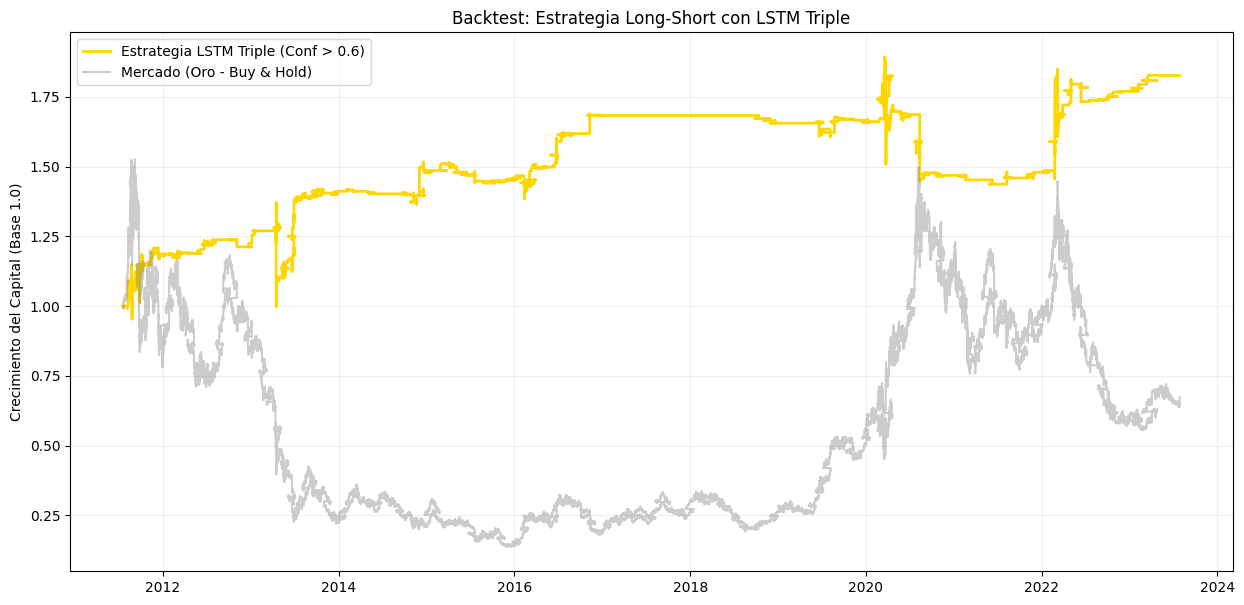

------------------------------
💰 NUEVO Sharpe Ratio: 0.67
📈 Retorno Total: 82.66%
🎯 Win Rate (de los trades): 54.34%
📊 Ratio de Operatividad: 1.59% (tiempo en mercado)
📉 Total de Trades: 2131 de 133712 velas
------------------------------


In [17]:
plot_triple_trading_results(result_triple, 0.6)

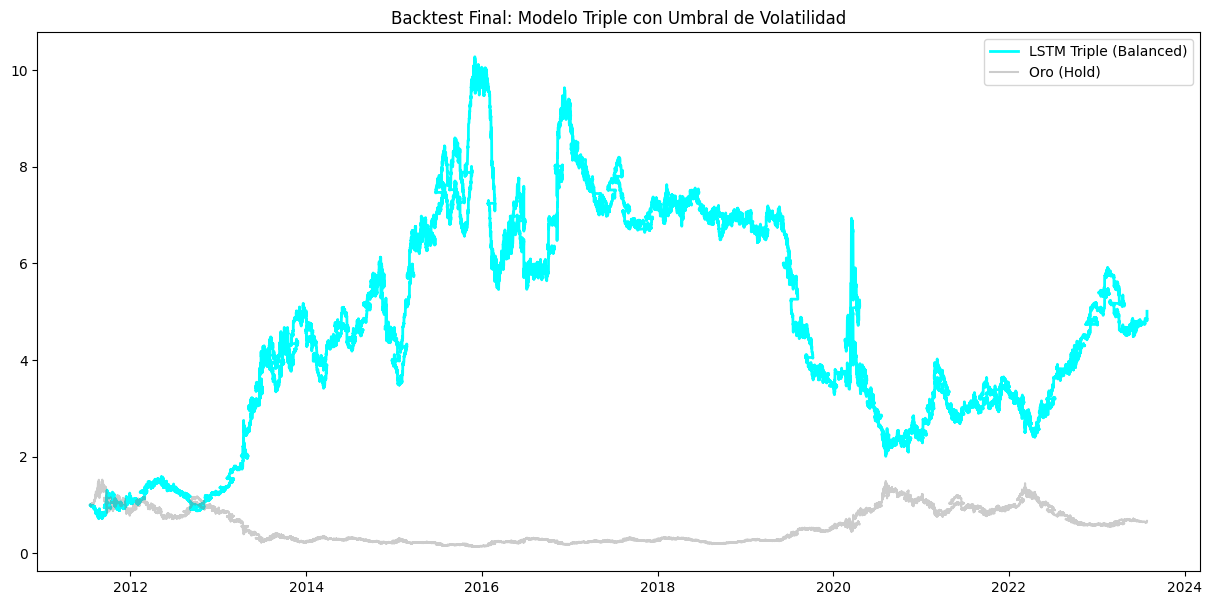

💰 Sharpe Ratio Esperado: 0.65


In [18]:
plot_triple_final_comparison(result_triple)

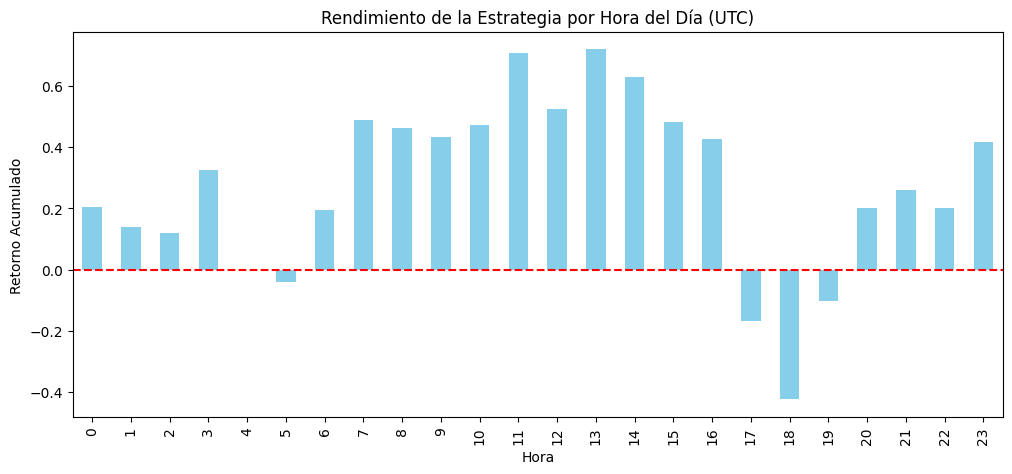

In [19]:
analyze_by_hour(result_triple)

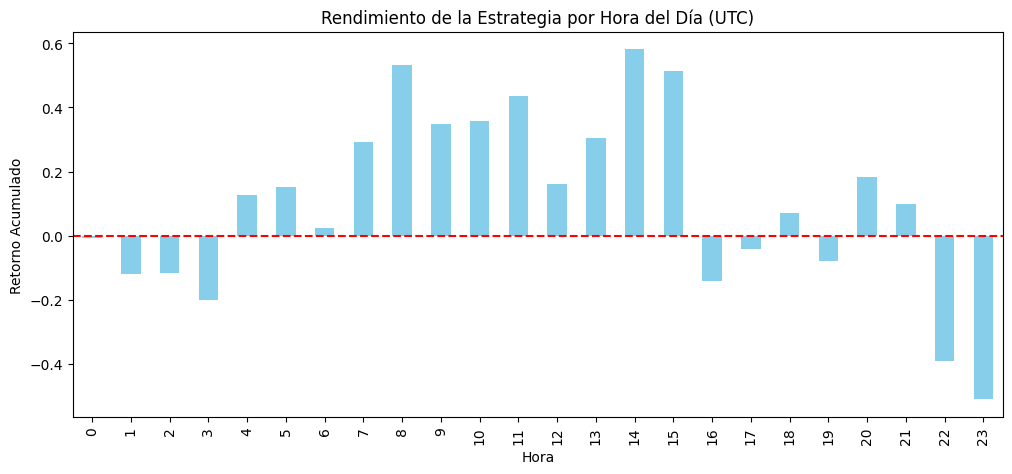

In [20]:
analyze_by_hour(result_torch)

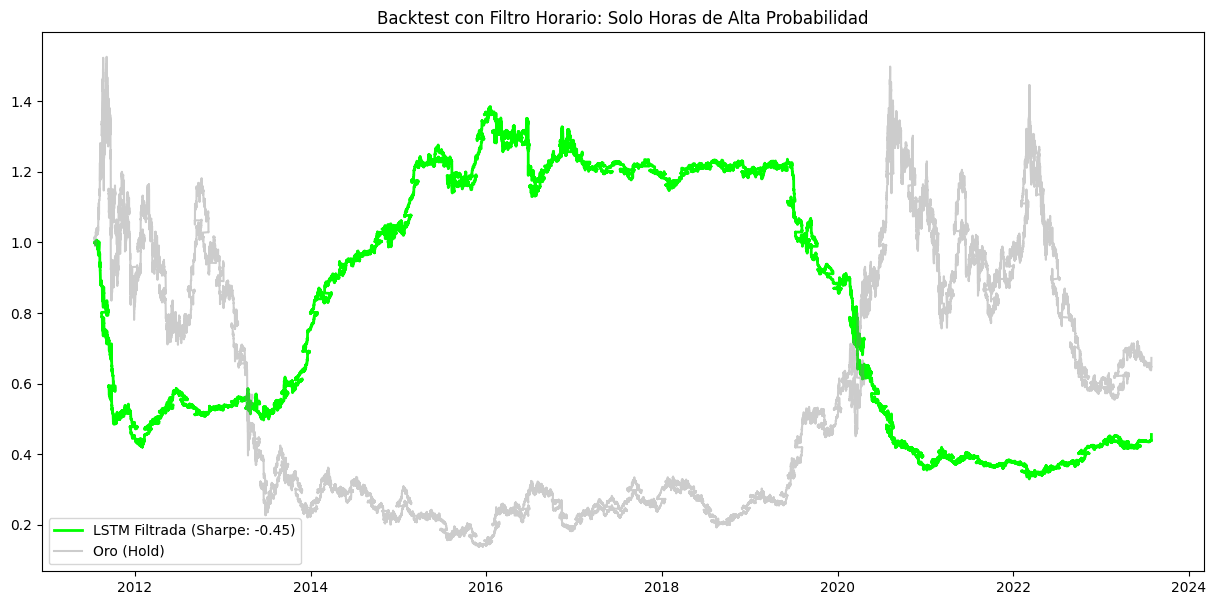

🚀 Sharpe Ratio con Filtro: -0.45


In [21]:
plot_backtest_filtrado(result_triple)

In [22]:
print(f"📊 El Sharpe Ratio REAL de este modelo es: {calculate_real_sharpe_binary(result_torch):.4f}")

✅ Análisis del Modelo Binario:
-------------------------------
💰 Retorno Acumulado Estrategia: 11.4572
📈 Retorno Acumulado Mercado:    0.6727
📊 El Sharpe Ratio REAL de este modelo es: 1.0942


In [23]:
calculate_sharpe_triple(result_triple)

📈 Resultado Final:
-------------------
💰 Sharpe Ratio: 2.0885
🚀 Retorno Total: 49478.26%
⚖️ Operaciones totales: 80472 de 133712


np.float64(2.0885108124120695)

In [24]:
calculate_final_binary_sharpe(result_torch)

📊 --- RESULTADOS BINARIOS ---
💰 Sharpe Ratio: 1.0942
📉 Volatilidad Anual: 22.47%
📈 Retorno Final: 11.4572
-------------------------------


np.float64(1.0941646050780744)

In [25]:
result_torch_filtered = apply_time_filter(result_torch) # Usa el df que tiene prob_up


🚀 Sharpe Original: 0.6245
💎 Sharpe Filtrado: 0.0194


In [26]:
stress_test_with_costs(result_torch_filtered, 0.0002)


🧪 --- STRESS TEST (1 TICK COST) ---
📉 Sharpe con Costes: -1.2081
💰 Retorno Final tras costes: 0.1179
🚪 Total de entradas pagadas: 10225
------------------------------------


np.float64(-1.2080822658826775)

In [27]:
# Sobre el dataframe original de 3028 operaciones
avg_ret_per_trade = result_torch_filtered[result_torch_filtered['signal_final'] == 1]['ret_real'].mean()
print(f"Retorno medio por trade: {avg_ret_per_trade:.6f}")

Retorno medio por trade: 0.000001


In [28]:
close_map = df_final_dict[f'{MINUTES}min'].set_index('datetime')['close']
result_torch_filtered['close'] = result_torch_filtered['datetime'].map(close_map)

In [29]:
run_backtest_pro(result_torch_filtered, tp_ticks=8, sl_ticks=4)

🏆 Resultado con Gestión de Riesgo (TP:8 / SL:4 ticks):
📊 Sharpe Neto: 6.2719
💰 Retorno Total: 4.4656


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.501177,0.000815,0.000815,1.000815,1.000815,1,4,0,0.000000,1594.5,0.000000
1,2011-07-18 05:00:00,1,1,0.548533,0.002067,0.002067,1.002884,1.002884,1,5,1,0.002067,1594.6,0.000439
2,2011-07-18 06:00:00,1,1,0.541494,0.001002,0.001002,1.003889,1.003889,1,6,1,0.001002,1595.8,0.000439
3,2011-07-18 07:00:00,1,1,0.527931,0.000313,0.000313,1.004203,1.004203,1,7,0,0.000000,1597.9,0.000000
4,2011-07-18 08:00:00,1,1,0.510489,0.001189,0.001189,1.005397,1.005397,1,8,0,0.000000,1597.4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,0,0.418488,-0.000765,-0.000000,11.022825,0.647310,0,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,0,0.443717,-0.000153,-0.000000,11.022825,0.647211,0,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,0,1,0.500766,-0.000357,-0.000357,11.018885,0.646980,1,21,0,-0.000000,1958.8,0.000000
133710,2023-07-28 22:00:00,1,1,0.569515,0.020116,0.020116,11.240540,0.659994,1,22,0,0.000000,1958.7,0.000000


In [30]:
run_backtest_managed_with_costs(result_torch_filtered, tp_ticks=40, sl_ticks=20, cost_in_ticks=2, tick_val=0.0001)

✅ TP: 40 | SL: 20 | Coste: 2 ticks
📊 Sharpe Neto Final: 14.8109
💰 Retorno Acumulado: 1.0197


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.501177,0.000815,0.000815,1.000815,1.000815,1,4,0,0.000000,1594.5,0.000000
1,2011-07-18 05:00:00,1,1,0.548533,0.002067,0.002067,1.002884,1.002884,1,5,1,0.002067,1594.6,0.000002
2,2011-07-18 06:00:00,1,1,0.541494,0.001002,0.001002,1.003889,1.003889,1,6,1,0.001002,1595.8,0.000002
3,2011-07-18 07:00:00,1,1,0.527931,0.000313,0.000313,1.004203,1.004203,1,7,0,0.000000,1597.9,0.000000
4,2011-07-18 08:00:00,1,1,0.510489,0.001189,0.001189,1.005397,1.005397,1,8,0,0.000000,1597.4,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,0,0.418488,-0.000765,-0.000000,11.022825,0.647310,0,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,0,0.443717,-0.000153,-0.000000,11.022825,0.647211,0,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,0,1,0.500766,-0.000357,-0.000357,11.018885,0.646980,1,21,0,-0.000000,1958.8,0.000000
133710,2023-07-28 22:00:00,1,1,0.569515,0.020116,0.020116,11.240540,0.659994,1,22,0,0.000000,1958.7,0.000000


In [31]:
import shap

def run_shap_analysis(model, train_loader, test_loader, feature_names):
    # 1. Preparar una muestra de datos (SHAP necesita tensores de fondo)
    # Tomamos el primer batch del train_loader como "background"
    batch_train_x, _ = next(iter(train_loader))
    batch_test_x, _ = next(iter(test_loader))
    
    # SHAP en PyTorch prefiere trabajar con tensores en CPU para la explicación
    model.cpu()
    background = batch_train_x[:100].cpu() # 100 ejemplos de fondo son suficientes
    test_samples = batch_test_x[:20].cpu()   # Explicamos las primeras 20 predicciones
    
    # 2. Inicializar el Explainer
    # DeepExplainer es ideal para redes neuronales
    explainer = shap.DeepExplainer(model, background)
    
    # 3. Calcular valores SHAP
    shap_values = explainer.shap_values(test_samples)
    
    # 4. Visualización
    print("📊 Generando Summary Plot...")
    # Como los datos son [batch, window, features], colapsamos el tiempo 
    # para ver la importancia general de la feature
    shap_values_collapsed = np.mean(np.abs(shap_values), axis=1) 
    
    shap.summary_plot(
        shap_values_collapsed, 
        features=test_samples.mean(dim=1).numpy(), 
        feature_names=feature_names,
        plot_type="bar"
    )

# Uso:
# run_shap_analysis(model_torch, train_loader, test_loader, feature_cols)

In [54]:
def explain_gold_model(model, df_test, feature_cols, lookback, scaler):
    # 1. Mover modelo a CPU y poner en modo entrenamiento (necesario para SHAP)
    model.cpu()
    model.train() 
    
    # Desactivamos capas que cambian el comportamiento en train
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.BatchNorm1d)):
            module.eval()

    # 2. Preparación de datos (Directo en CPU)
    df_test_scaled = df_test.copy()
    df_test_scaled[feature_cols] = scaler.transform(df_test_scaled[feature_cols])
    
    X_test_shap, _ = create_lstm_dataset(df_test_scaled, feature_cols, target_col='target_bin', lookback=lookback)
    
    # Aseguramos tensores en CPU y Float32
    X_tensor = torch.tensor(X_test_shap, dtype=torch.float32).cpu()
    
    # 3. Muestras para el análisis
    # Usar 50 de fondo y 20 para explicar es suficiente para ver la tendencia
    background = X_tensor[:50] 
    test_samples = X_tensor[50:70] 
    
    # 4. Explicador SHAP
    # DeepExplainer funciona bien con LSTMs en CPU
    explainer = shap.DeepExplainer(model, background)
    
    # # 5. Cálculo de valores SHAP
    # print("⏳ Calculando valores SHAP (esto puede tardar un minuto en CPU)...")
    # shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # # 6. Procesamiento de dimensiones
    # # SHAP devuelve una lista por salida. Para clasificación binaria, tomamos [0] o [1]
    # shap_val_array = np.array(shap_values)
    
    # # Si la forma es [muestras, tiempo, features], promediamos el tiempo
    # if len(shap_val_array.shape) == 4: # [outputs, samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array[0]).mean(axis=1)
    # else: # [samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array).mean(axis=1)

    # print("📊 SHAP Summary Plot:")
    # shap.summary_plot(
    #     shap_val_avg, 
    #     features=test_samples.mean(dim=1).numpy(), 
    #     feature_names=feature_cols,
    #     plot_type="bar" # Tipo barras para ver importancia clara
    # )
    # 5. Cálculo de valores SHAP
    shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # 6. Normalización de dimensiones - VERSIÓN FINAL
    if isinstance(shap_values, list):
        # En clasificación binaria con DeepExplainer, a veces devuelve [muestras, tiempo, features, salidas]
        # Tomamos la salida 1
        shap_val_array = np.array(shap_values[-1]) 
    else:
        shap_val_array = np.array(shap_values)

    print(f"DEBUG: Shape original SHAP: {shap_val_array.shape}")

    # 7. Colapsar el Lookback (la dimensión del tiempo)
    # Si es (20, 24, 27) -> queremos (20, 27)
    if len(shap_val_array.shape) == 3:
        # Hacemos la media del impacto absoluto en las 24 horas
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
    elif len(shap_val_array.shape) == 4:
        # Si viene con (muestras, tiempo, features, salida)
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
        if len(shap_val_final.shape) == 3: # (muestras, features, 1)
            shap_val_final = shap_val_final.reshape(shap_val_final.shape[0], shap_val_final.shape[1])
    else:
        shap_val_final = shap_val_array

    # 8. Preparar X_plot coincidente (20, 27)
    # Colapsamos el tiempo de las muestras de entrada también para el gráfico
    if len(test_samples.shape) == 3:
        X_plot = test_samples.mean(dim=1).numpy()
    else:
        X_plot = test_samples.numpy()

    print(f"✅ Ajuste final: SHAP {shap_val_final.shape} | Features {X_plot.shape}")

    # 9. Generar el gráfico
    shap.summary_plot(
        shap_val_final, 
        features=X_plot, 
        feature_names=feature_cols,
        plot_type="bar"
    )
    # OPCIONAL: Devolver el modelo a la GPU si vas a seguir usándolo
    # model.cuda()

In [55]:
df_test_reciente = df_final_dict[f'{MINUTES}min'].tail(1000).copy()

c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


DEBUG: Shape original SHAP: (20, 24, 27, 1)
✅ Ajuste final: SHAP (20, 27) | Features (20, 27)


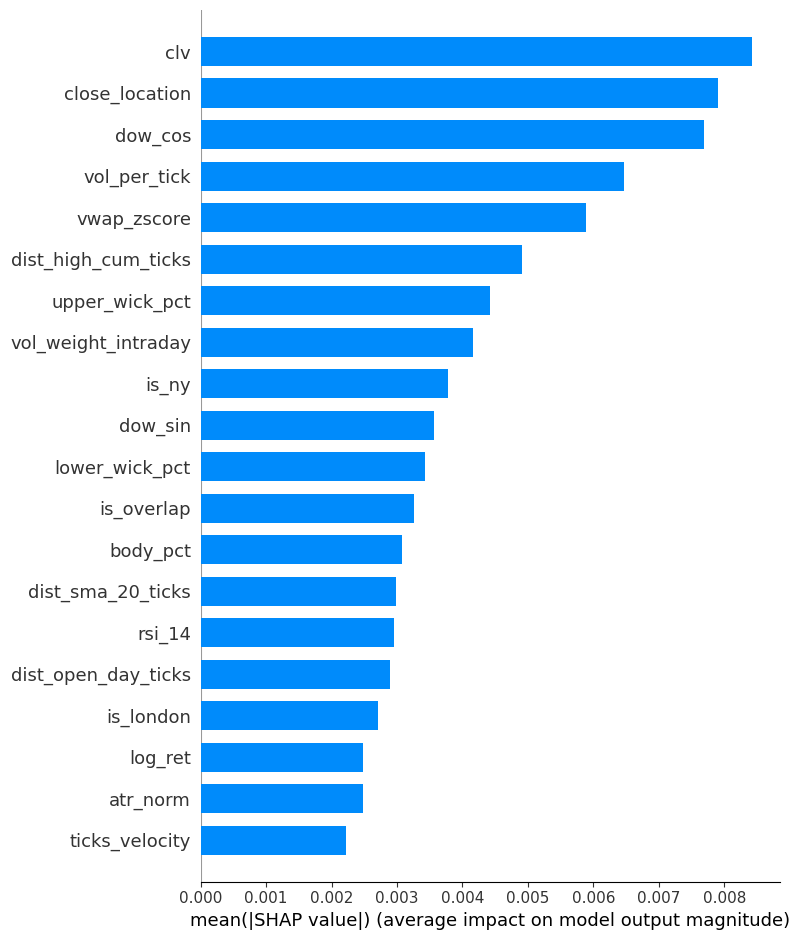

In [56]:
explain_gold_model(model, df_test_reciente, FEATURE_COLUMNS, 24, sc)